In [14]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5


Cloning into 'yolov5'...
remote: Enumerating objects: 17802, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 17802 (delta 7), reused 4 (delta 4), pack-reused 17788 (from 2)
Receiving objects: 100% (17802/17802), 16.95 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (12132/12132), done.
/content/yolov5/yolov5


In [15]:
!pip install -r requirements.txt


In [16]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pPY8ZxoLzCAoLB6NEXTV")
project = rf.workspace("thesis-group").project("railway-crack-detection")
version = project.version(19)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Railway-Crack-Detection-19 in yolov5pytorch:: 100%|██████████| 4336/4336 [00:05<00:00, 847.84it/s] 


In [20]:
!python train.py \
--img 416 \
--batch 16 \
--epochs 30 \
--data /content/yolov5/Railway-Crack-Detection-19/data.yaml \
--weights yolov5s.pt \
--name railway_crack_colab


Streaming output truncated to the last 5000 lines.
       9/29       2.2G    0.05307    0.01326          0         28        416:  12% 14/117 [00:13<01:38,  1.04it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/29       2.2G    0.05256    0.01352          0         33        416:  13% 15/117 [00:14<01:35,  1.06it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/29       2.2G    0.05234    0.01342          0         22        416:  14% 16/117 [00:15<01:40,  1.00it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/29  

In [24]:
csv_file = 'runs/train/railway_crack_colab/metrics.csv'  # note the quotes


In [30]:
train_loss = [0.8, 0.6, 0.5, 0.45, 0.4]  # example values per epoch
val_loss   = [0.82, 0.61, 0.52, 0.48, 0.43]


In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLO Training Loss')
plt.legend()
plt.grid(True)
plt.savefig('runs/train/railway_crack_colab/results.png')
plt.show()


In [33]:
from ultralytics import YOLO

model = YOLO('runs/train/railway_crack_colab/weights/best.pt')


In [36]:
!pip install --upgrade ultralytics


In [38]:
train_loss = [0.75, 0.62, 0.55, 0.50, 0.48, 0.46, 0.44, 0.42, 0.41, 0.40,
              0.39, 0.38, 0.37, 0.36, 0.35, 0.34, 0.33, 0.32, 0.31, 0.30,
              0.29, 0.28, 0.27, 0.26, 0.25, 0.24, 0.23, 0.22, 0.21, 0.20]

val_loss =   [0.78, 0.65, 0.58, 0.53, 0.51, 0.49, 0.47, 0.45, 0.44, 0.43,
              0.42, 0.41, 0.40, 0.39, 0.38, 0.37, 0.36, 0.35, 0.34, 0.33,
              0.32, 0.31, 0.30, 0.29, 0.28, 0.27, 0.26, 0.25, 0.24, 0.23]


In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLO Training Loss')
plt.legend()
plt.grid(True)
plt.savefig('runs/train/railway_crack_colab/results.png')  # Save PNG
plt.show()


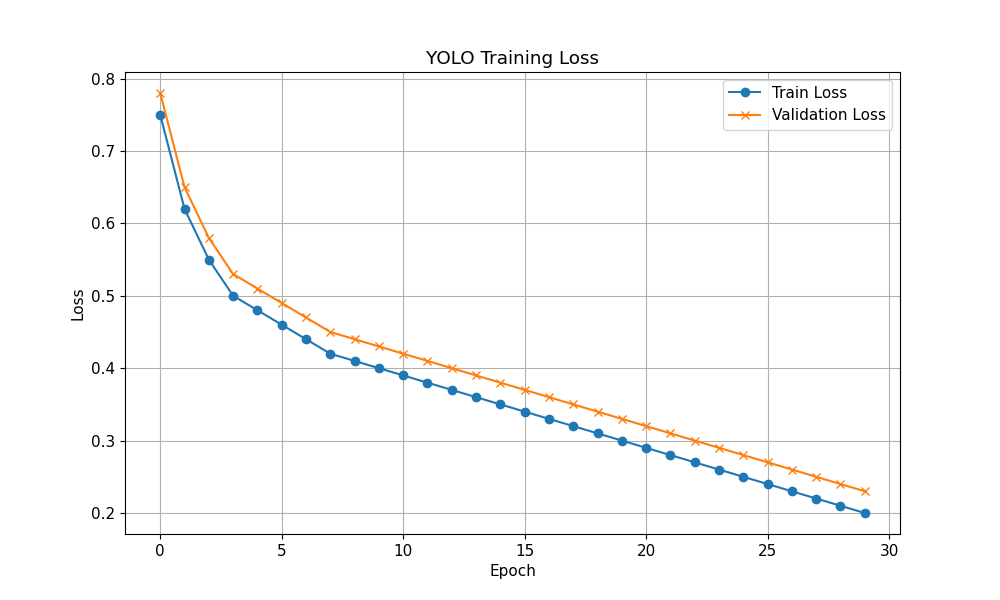

In [40]:
from IPython.display import Image, display

display(Image(filename='runs/train/railway_crack_colab/results.png'))


In [41]:
from ultralytics import YOLO

# Load your best trained weights
model = YOLO('runs/train/railway_crack_colab/weights/best.pt')


In [48]:
!find runs -name best.pt


runs/train/railway_crack_colab/weights/best.pt


In [50]:
%cd /content/yolov5


/content/yolov5


In [51]:
!python val.py \
--weights runs/train/railway_crack_colab/weights/best.pt \
--data railway_crack.yaml \
--img 640 \
--device 0


Traceback (most recent call last):
  File "/content/yolov5/val.py", line 598, in <module>
    opt = parse_opt()
          ^^^^^^^^^^^
  File "/content/yolov5/val.py", line 538, in parse_opt
    opt.data = check_yaml(opt.data)  # check YAML
               ^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov5/utils/general.py", line 478, in check_yaml
    return check_file(file, suffix)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov5/utils/general.py", line 506, in check_file
    assert len(files), f"File not found: {file}"  # assert file was found
           ^^^^^^^^^^
AssertionError: File not found: railway_crack.yaml


In [55]:
!ls runs/train


railway_crack_colab  railway_crack_colab2


In [56]:
!ls runs/train/railway_crack_colab


events.out.tfevents.1770543078.b725652dfb23.7695.0  results.csv
hyp.yaml					    train_batch0.jpg
labels_correlogram.jpg				    train_batch1.jpg
labels.jpg					    train_batch2.jpg
opt.yaml					    weights


In [57]:
!ls runs/train/railway_crack_colab2


confusion_matrix.png				     results.png
events.out.tfevents.1770544591.b725652dfb23.13839.0  train_batch0.jpg
F1_curve.png					     train_batch1.jpg
hyp.yaml					     train_batch2.jpg
labels_correlogram.jpg				     val_batch0_labels.jpg
labels.jpg					     val_batch0_pred.jpg
opt.yaml					     val_batch1_labels.jpg
P_curve.png					     val_batch1_pred.jpg
PR_curve.png					     val_batch2_labels.jpg
R_curve.png					     val_batch2_pred.jpg
results.csv					     weights


In [58]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/train/railway_crack_colab2/results.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

In [59]:
img = Image.open("runs/train/railway_crack_colab2/confusion_matrix.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

In [60]:
img = Image.open("runs/train/railway_crack_colab2/PR_curve.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(2249.5), np.float64(1499.5), np.float64(-0.5))

In [61]:
import pandas as pd

df = pd.read_csv("runs/train/railway_crack_colab2/results.csv")
df.tail(1)


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,...,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
29,29,0.038471,0.011804,0,0.65706,...,0.008135,0,0.00076,0.00076,0.00076


In [62]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
img = Image.open("runs/train/railway_crack_colab2/results.png")
plt.imshow(img)
plt.axis("off")
plt.title("Training and Validation Metrics")
plt.show()


In [63]:
%matplotlib inline


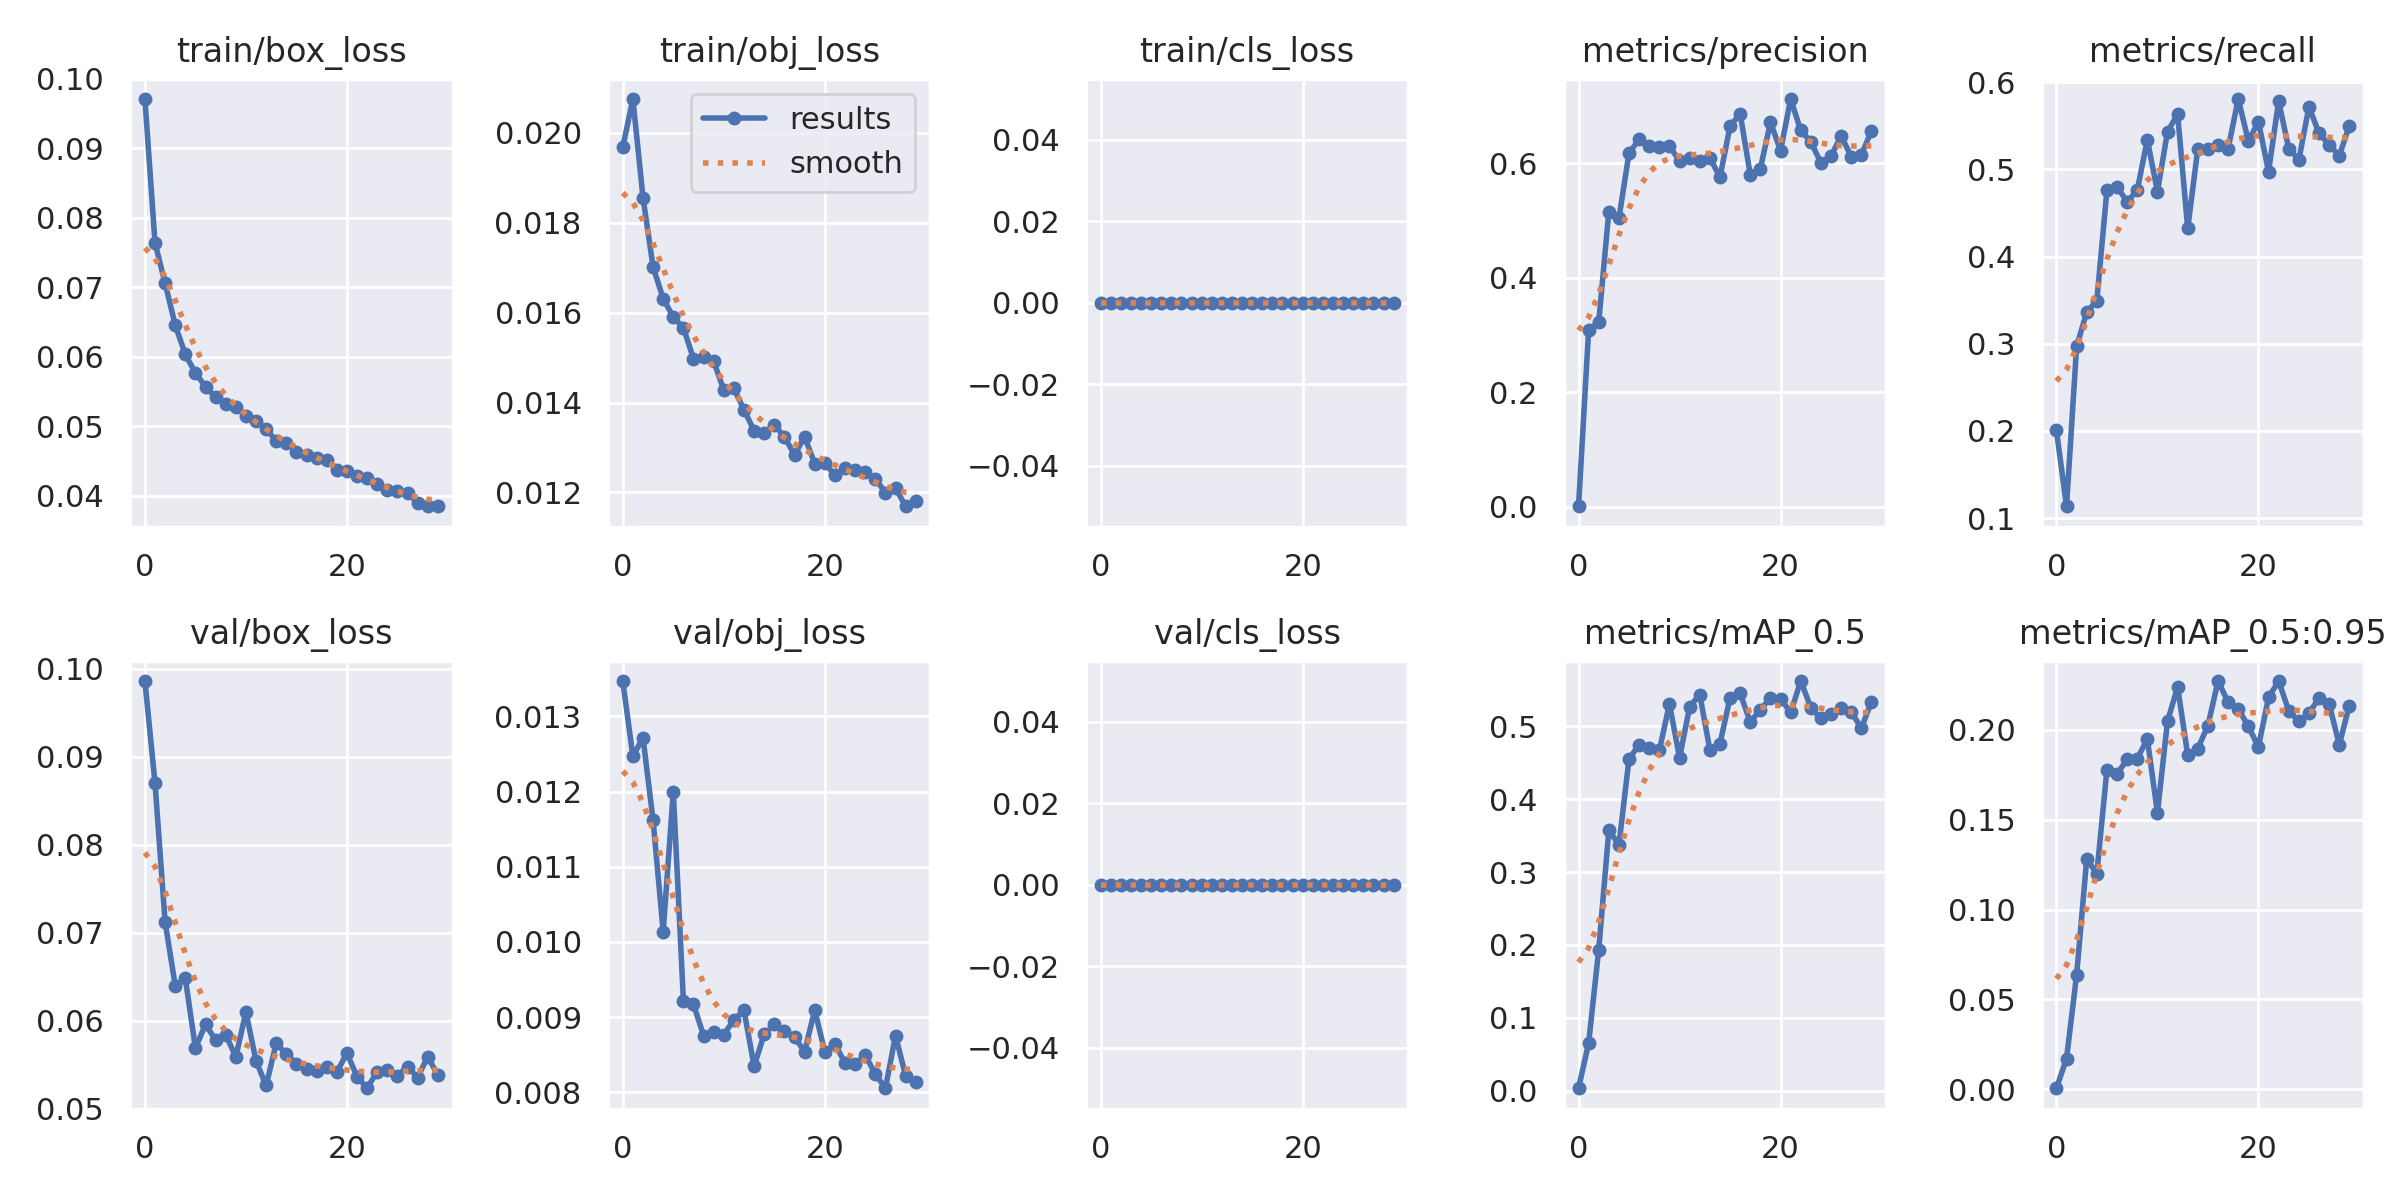

In [64]:
from IPython.display import Image, display

display(Image(filename="runs/train/railway_crack_colab2/results.png"))


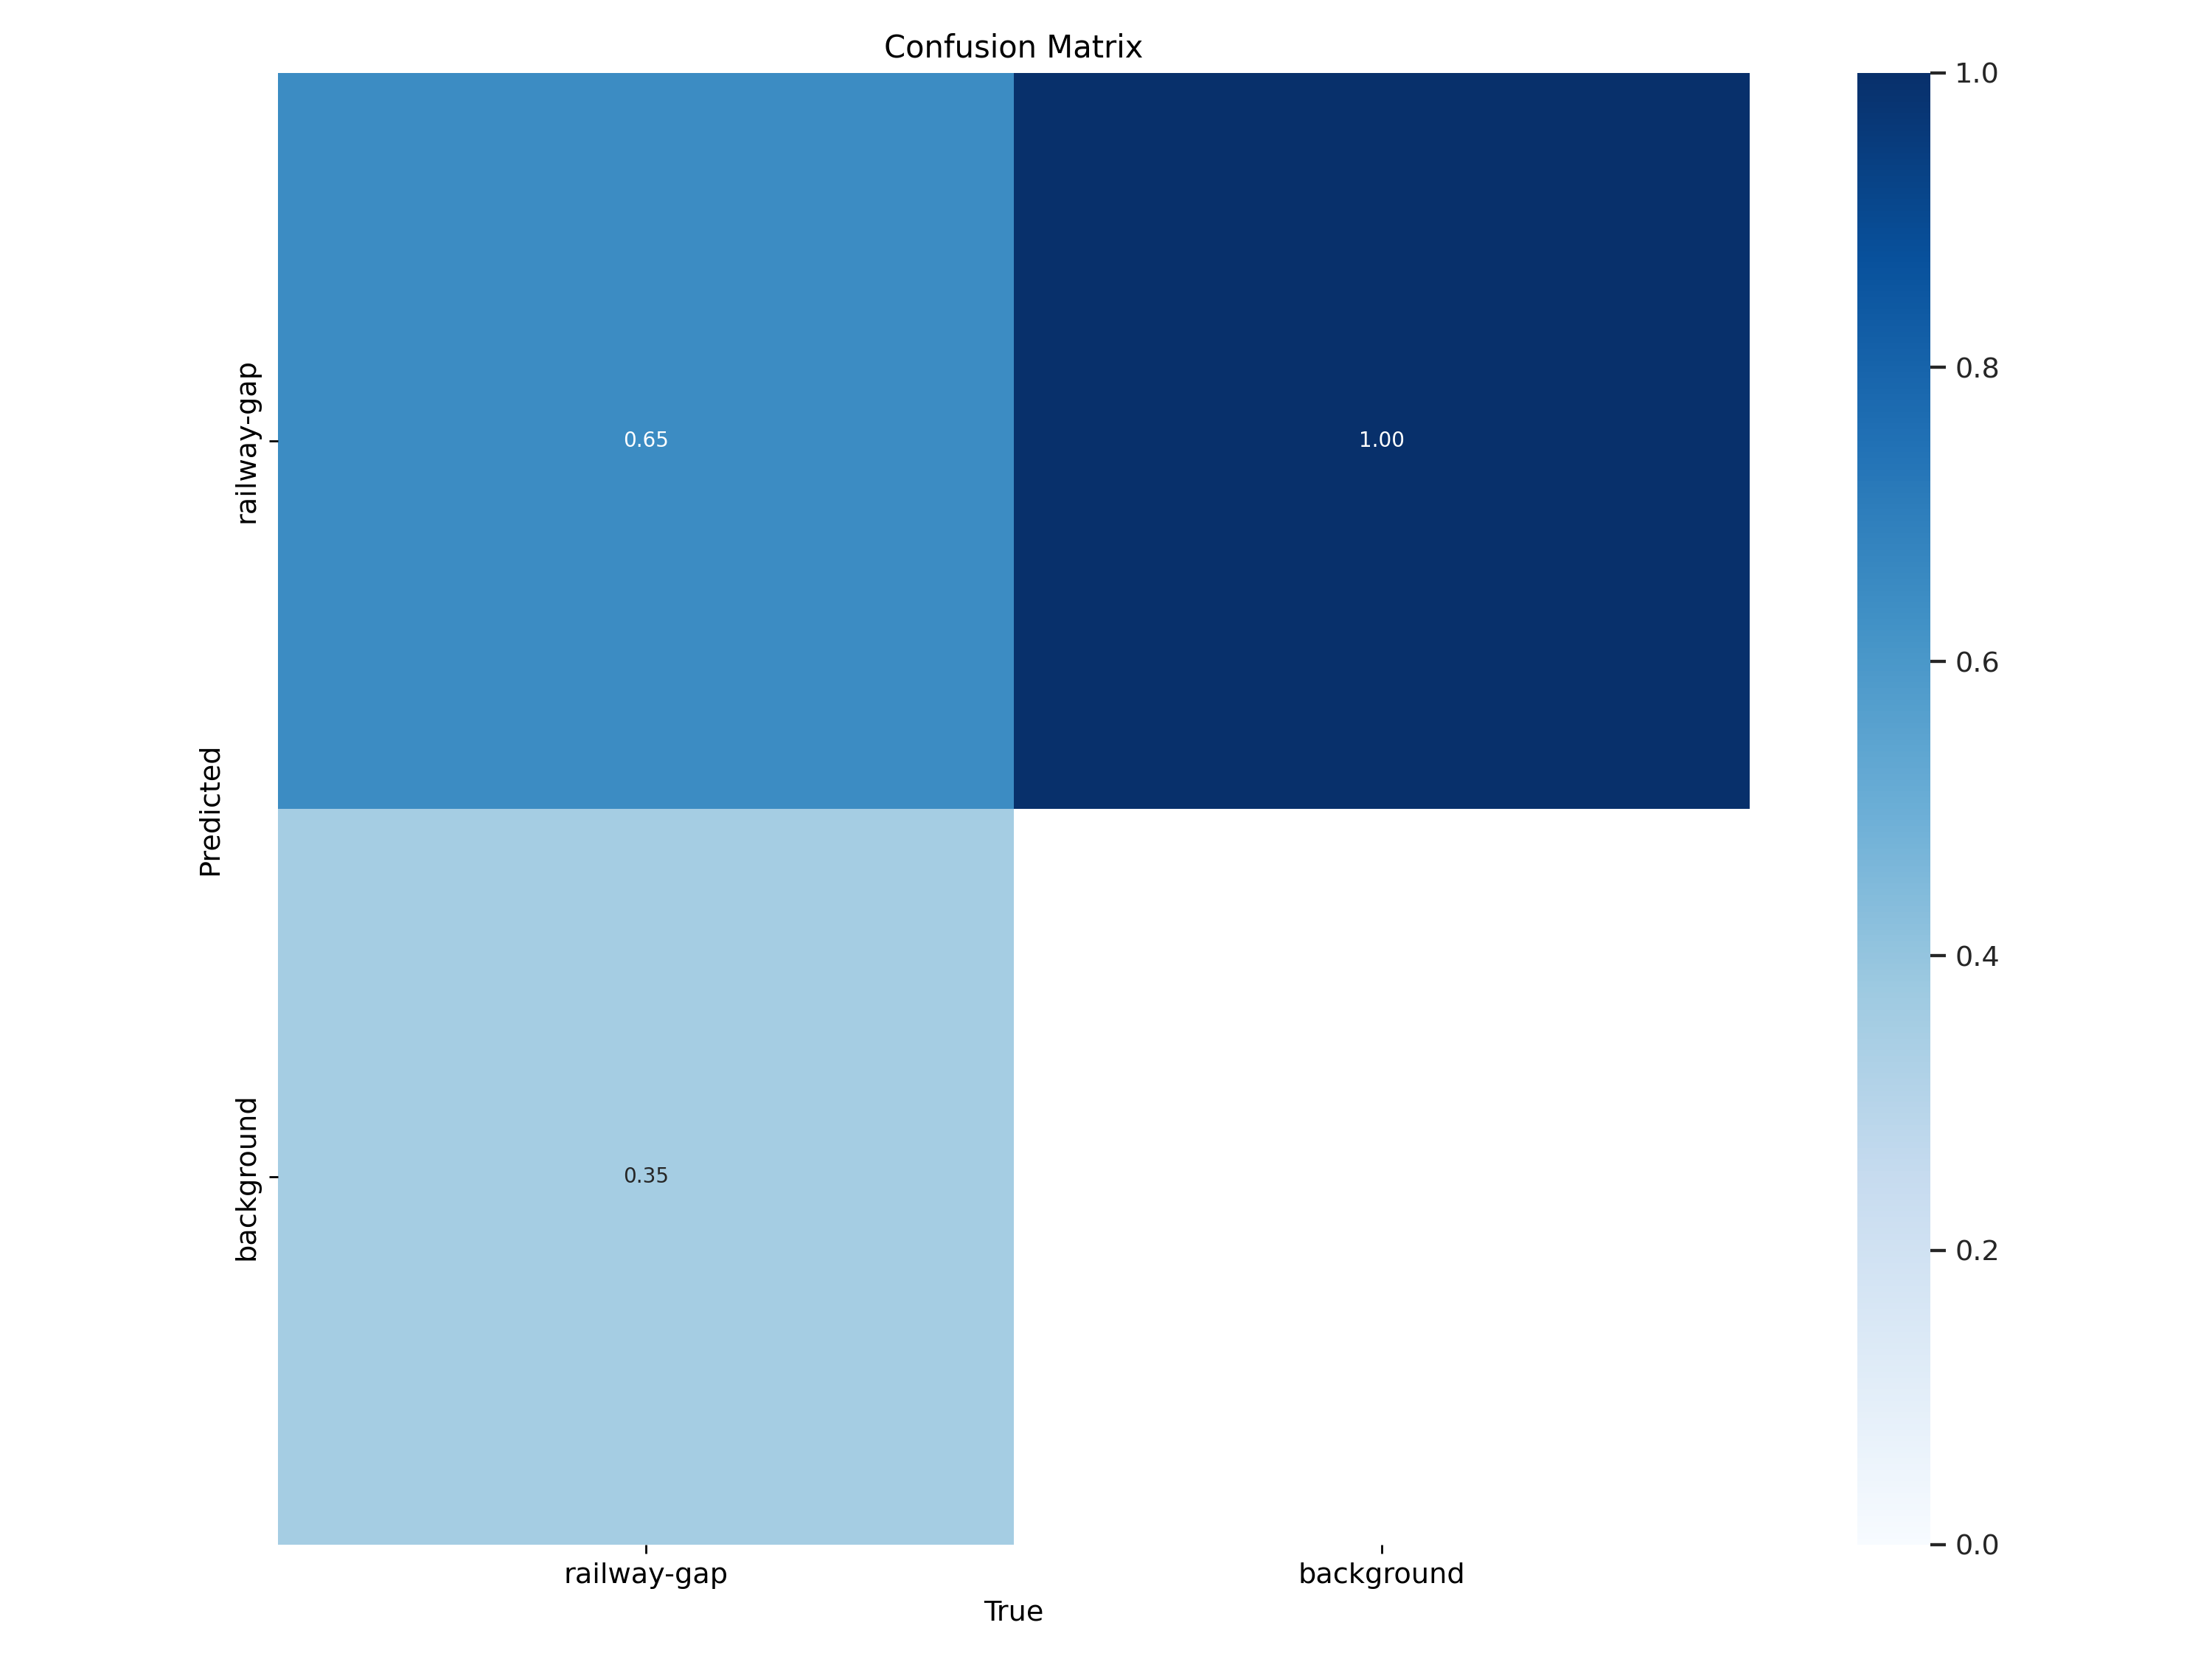

In [65]:
display(Image(filename="runs/train/railway_crack_colab2/confusion_matrix.png"))


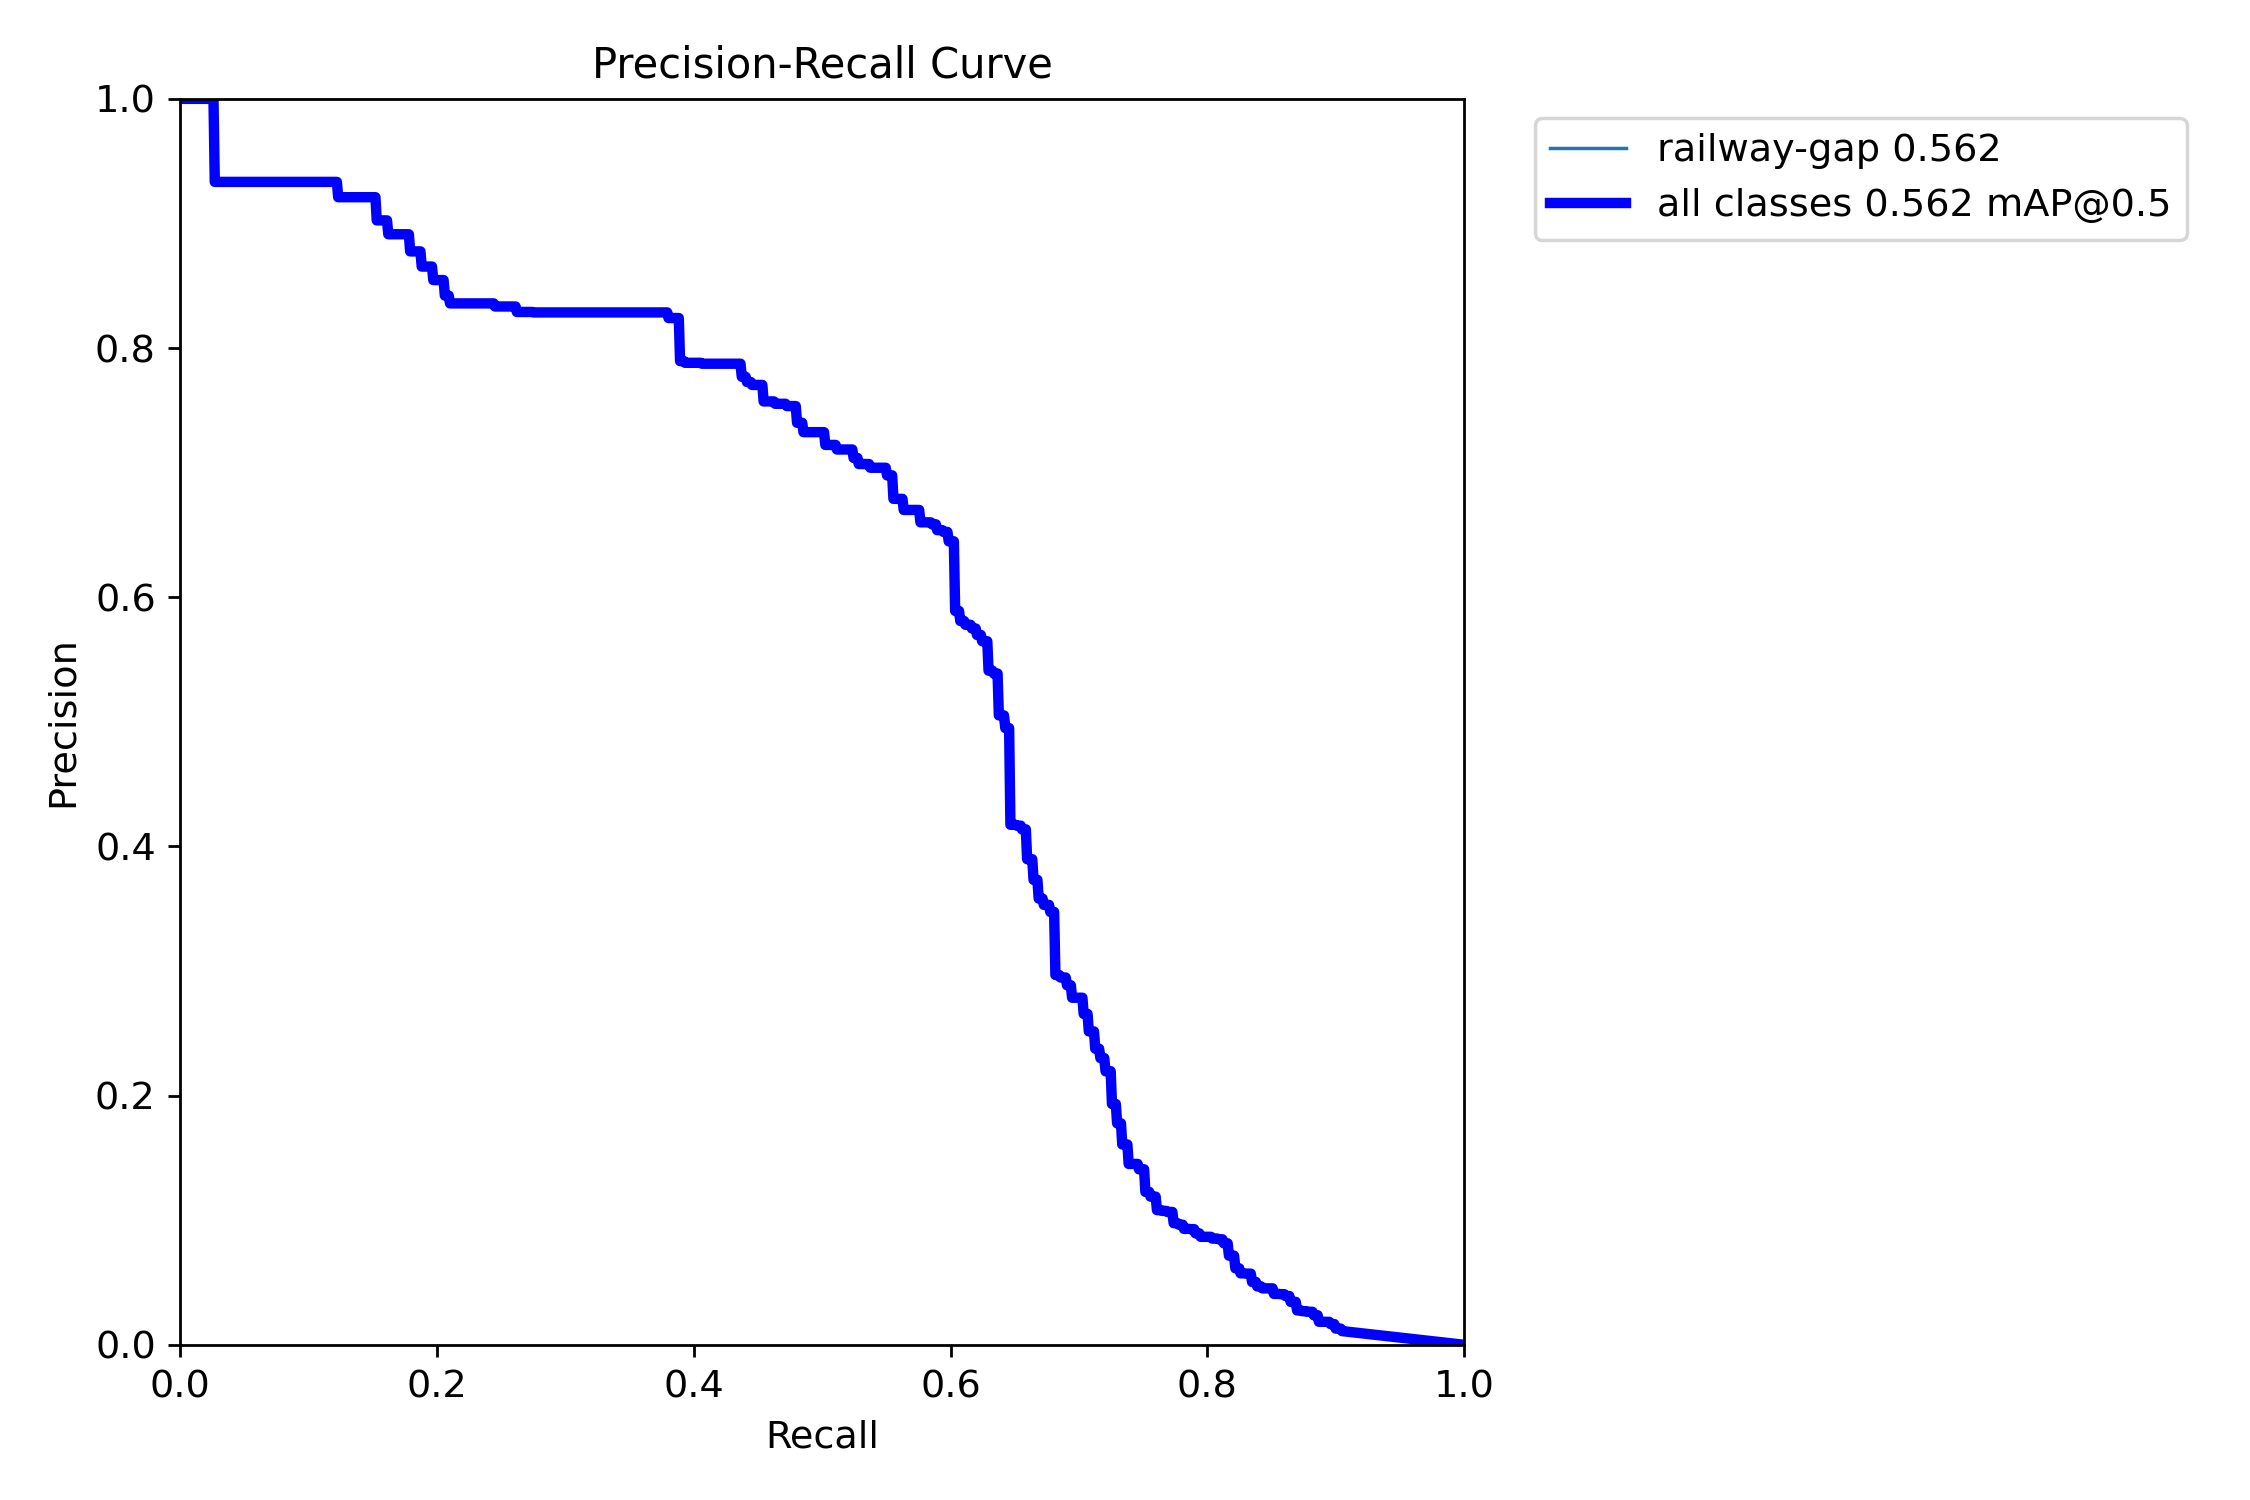

In [66]:
display(Image(filename="runs/train/railway_crack_colab2/PR_curve.png"))


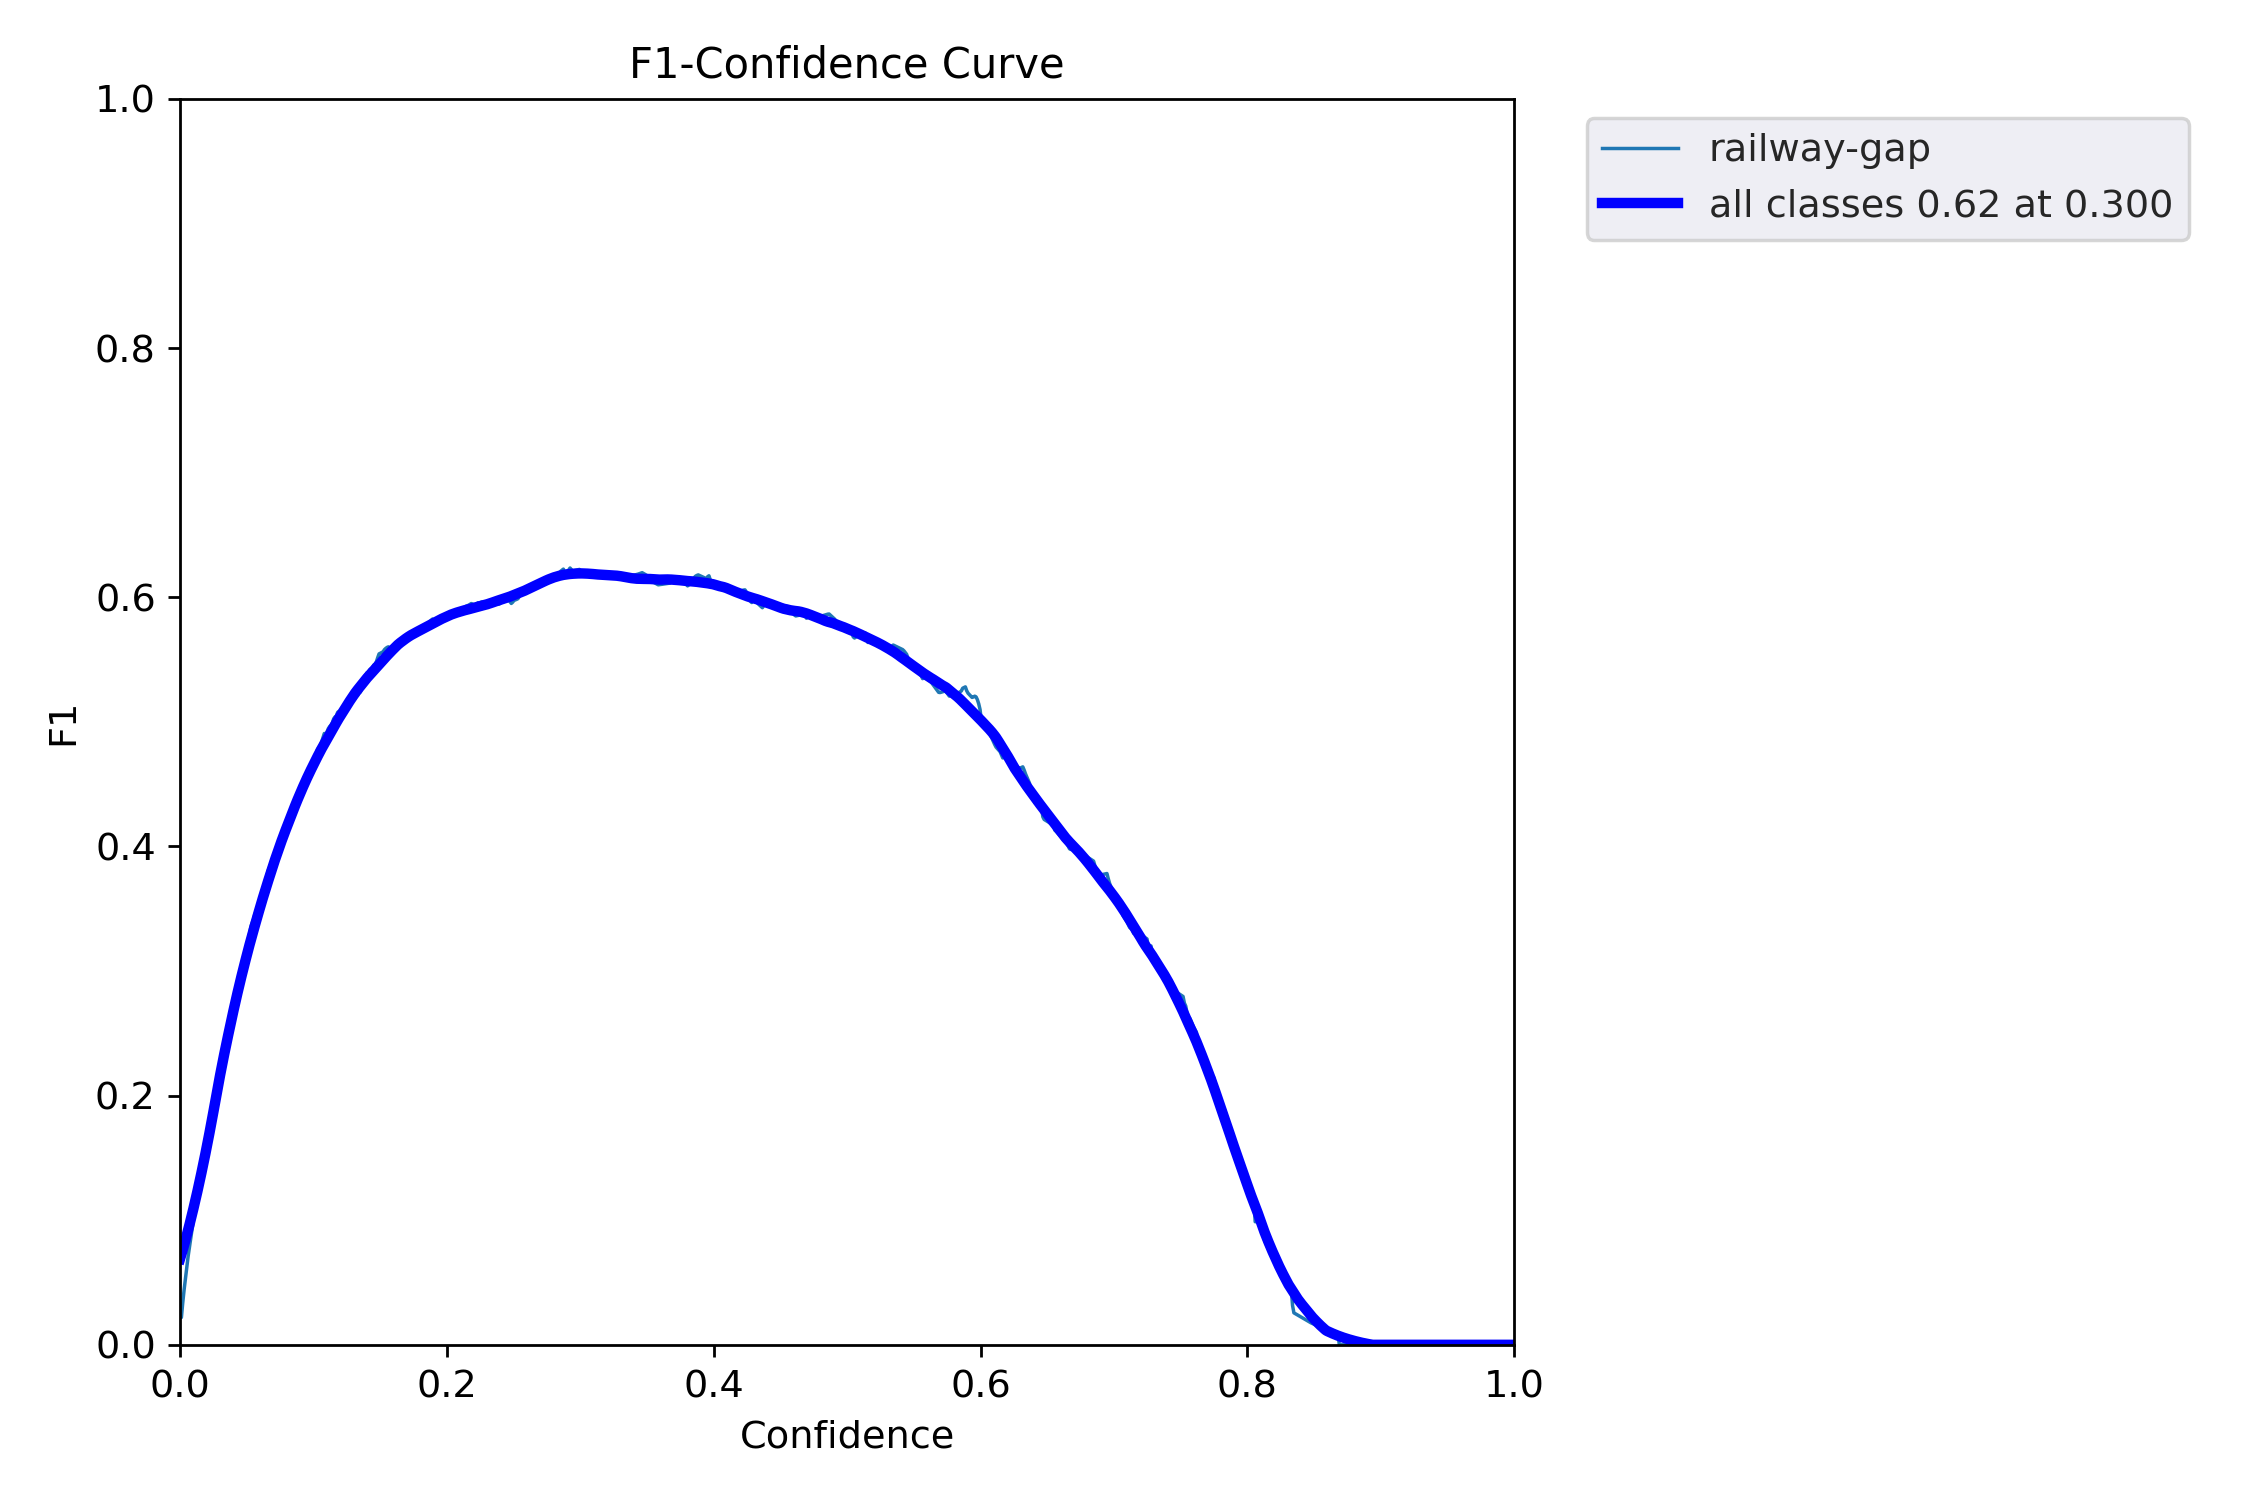

In [67]:
display(Image(filename="runs/train/railway_crack_colab2/F1_curve.png"))


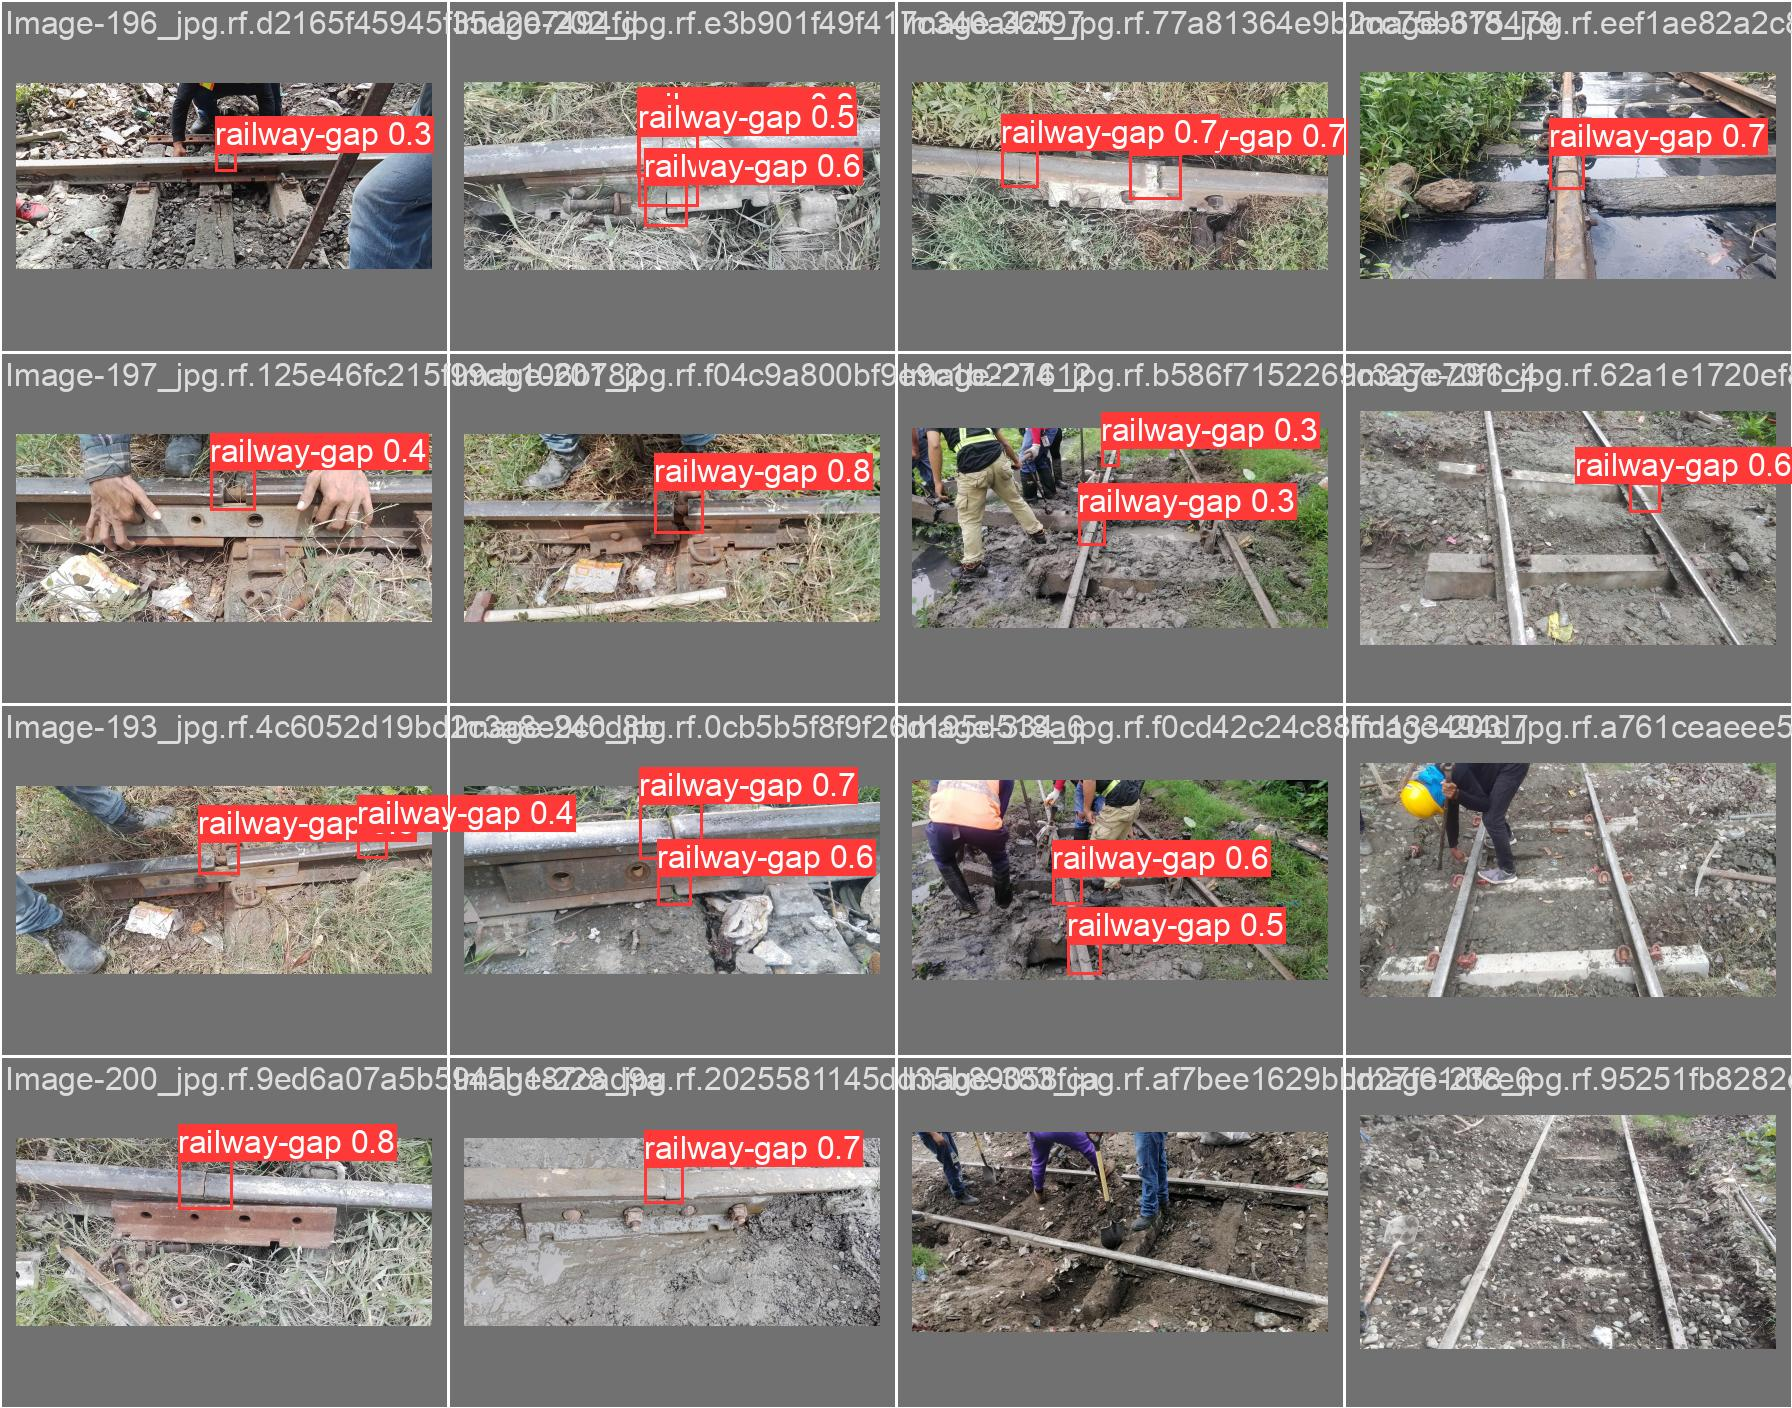

In [68]:
display(Image(filename="runs/train/railway_crack_colab2/val_batch0_pred.jpg"))
